In [3]:
# ── STEP 1: IMPORTS ──────────────────────────────────────

import os
import numpy as np
import pandas as pd
import librosa
import tensorflow as tf
from tensorflow.keras import layers, Model
from scipy.fftpack import dct
from scipy.optimize import brentq
from scipy.interpolate import interp1d
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

2026-06-21 13:46:12.519707: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782049572.704791      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782049572.759622      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782049573.215418      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782049573.215455      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782049573.215458      58 computation_placer.cc:177] computation placer alr

In [4]:
# ── STEP 2: CONFIGURATION + DATA LOADING (FIXED PATHS) ──────────────

# -----------------------------------------------------------
# 2A. CONFIGURATION
# -----------------------------------------------------------

SAMPLE_RATE  = 16000
MAX_DURATION = 4.0
MAX_SAMPLES  = int(SAMPLE_RATE * MAX_DURATION)

N_MELS       = 80
N_FFT        = 512
HOP_LENGTH   = 160
FMAX         = 8000
N_LFCC       = 60

BATCH_SIZE   = 32
SEED         = 42

# ── FIXED: correct path from your Kaggle dataset panel ──────
BASE_DIR = "/kaggle/input/datasets/awsaf49/asvpoof-2019-dataset"

# ── FIXED: your dataset has an extra nested folder LA/LA and PA/PA
LA_DIR   = os.path.join(BASE_DIR, "LA", "LA")
PA_DIR   = os.path.join(BASE_DIR, "PA", "PA")

print("Configuration done.")
print("MAX_SAMPLES per file:", MAX_SAMPLES, "(= 4 seconds at 16kHz)")
print("LA_DIR:", LA_DIR)
print("PA_DIR:", PA_DIR)

# quick check — confirm folders exist
for d in [LA_DIR, PA_DIR]:
    if os.path.exists(d):
        print("EXISTS : " + d)
    else:
        print("MISSING: " + d)

Configuration done.
MAX_SAMPLES per file: 64000 (= 4 seconds at 16kHz)
LA_DIR: /kaggle/input/datasets/awsaf49/asvpoof-2019-dataset/LA/LA
PA_DIR: /kaggle/input/datasets/awsaf49/asvpoof-2019-dataset/PA/PA
EXISTS : /kaggle/input/datasets/awsaf49/asvpoof-2019-dataset/LA/LA
EXISTS : /kaggle/input/datasets/awsaf49/asvpoof-2019-dataset/PA/PA


In [5]:
# -----------------------------------------------------------
# 2B. PROTOCOL PARSER — unchanged, works as before
# -----------------------------------------------------------

def parse_protocol(protocol_path):
    rows = []
    with open(protocol_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            rows.append({
                "speaker_id"  : parts[0],
                "file_id"     : parts[1],
                "attack_type" : parts[3],
                "label"       : parts[4],
                "label_int"   : 0 if parts[4] == "bonafide" else 1
            })
    return pd.DataFrame(rows)


# -----------------------------------------------------------
# 2C. LOAD PROTOCOLS — FIXED folder names to match your tree
# -----------------------------------------------------------

def load_protocols(subset="LA"):
    """
    Fixed to match your exact Kaggle folder structure:

    LA/LA/
        ASVspoof2019_LA_cm_protocols/
            ASVspoof2019.LA.cm.train.trn.txt
            ASVspoof2019.LA.cm.dev.trl.txt
            ASVspoof2019.LA.cm.eval.trl.txt
        ASVspoof2019_LA_train/
        ASVspoof2019_LA_dev/
        ASVspoof2019_LA_eval/
    """
    base      = LA_DIR if subset == "LA" else PA_DIR
    proto_dir = os.path.join(
        base,
        "ASVspoof2019_" + subset + "_cm_protocols"
    )

    splits = {
        "train" : "ASVspoof2019." + subset + ".cm.train.trn.txt",
        "dev"   : "ASVspoof2019." + subset + ".cm.dev.trl.txt",
        "eval"  : "ASVspoof2019." + subset + ".cm.eval.trl.txt",
    }

    protocols = {}

    for split, fname in splits.items():
        path = os.path.join(proto_dir, fname)

        if os.path.exists(path):
            df = parse_protocol(path)
            protocols[split] = df
            n_bonafide = (df.label == "bonafide").sum()
            n_spoof    = (df.label == "spoof").sum()
            print(subset + " | " + split
                  + " | total: "    + str(len(df))
                  + " | bonafide: " + str(n_bonafide)
                  + " | spoof: "    + str(n_spoof))
        else:
            print("NOT FOUND: " + path)

    return protocols

# -----------------------------------------------------------
# 2D. BUILD FILE LISTS — FIXED audio folder paths
# -----------------------------------------------------------

def build_file_list(df, audio_dir):
    """
    Matches file_id from protocol to actual .flac file on disk.

    Your folder structure from the Kaggle panel:
        ASVspoof2019_LA_train/   ← audio files directly inside
        ASVspoof2019_LA_dev/
        ASVspoof2019_LA_eval/

    NOTE: some Kaggle versions of this dataset store .flac files
    directly in the folder (no 'flac' subfolder).
    This function tries both and uses whichever exists.
    """
    file_paths = []
    labels     = []
    missing    = 0

    for _, row in df.iterrows():
        fid = row["file_id"]

        # try path WITH flac subfolder first
        path_with_sub = os.path.join(audio_dir, "flac", fid + ".flac")

        # try path WITHOUT flac subfolder (direct)
        path_direct   = os.path.join(audio_dir, fid + ".flac")

        if os.path.exists(path_with_sub):
            file_paths.append(path_with_sub)
            labels.append(row["label_int"])

        elif os.path.exists(path_direct):
            file_paths.append(path_direct)
            labels.append(row["label_int"])

        else:
            missing += 1

    if missing > 0:
        print("WARNING: " + str(missing) + " files not found on disk")

    return np.array(file_paths), np.array(labels, dtype=np.int32)


def compute_class_weights(labels):
    n_total    = len(labels)
    n_bonafide = (labels == 0).sum()
    n_spoof    = (labels == 1).sum()
    w_bonafide = n_total / (2.0 * n_bonafide)
    w_spoof    = n_total / (2.0 * n_spoof)
    print("Class weight — bonafide: " + str(round(w_bonafide, 3))
          + " | spoof: " + str(round(w_spoof, 3)))
    return {0: w_bonafide, 1: w_spoof}


# -----------------------------------------------------------
# 2E. RUN IT — with your corrected folder names
# -----------------------------------------------------------

print("Loading LA protocols...")
la_protocols = load_protocols("LA")

# ── FIXED: audio folder paths using your exact folder names ──
train_audio_dir = os.path.join(LA_DIR, "ASVspoof2019_LA_train")
dev_audio_dir   = os.path.join(LA_DIR, "ASVspoof2019_LA_dev")
eval_audio_dir  = os.path.join(LA_DIR, "ASVspoof2019_LA_eval")

print("\nBuilding file lists...")
train_paths, train_labels = build_file_list(
    la_protocols["train"], train_audio_dir
)
dev_paths, dev_labels = build_file_list(
    la_protocols["dev"], dev_audio_dir
)
eval_paths, eval_labels = build_file_list(
    la_protocols["eval"], eval_audio_dir
)

print("\nTrain files found : " + str(len(train_paths)))
print("Dev   files found : " + str(len(dev_paths)))
print("Eval  files found : " + str(len(eval_labels)))

# compute class weights for training
class_weights = compute_class_weights(train_labels)

Loading LA protocols...
LA | train | total: 25380 | bonafide: 2580 | spoof: 22800
LA | dev | total: 24844 | bonafide: 2548 | spoof: 22296
LA | eval | total: 71237 | bonafide: 7355 | spoof: 63882

Building file lists...

Train files found : 25380
Dev   files found : 24844
Eval  files found : 71237
Class weight — bonafide: 4.919 | spoof: 0.557


In [6]:
# -----------------------------------------------------------
# 3A. AUDIO LOADER + PAD/TRIM
# -----------------------------------------------------------

def load_audio(file_path):
    """
    Loads a .flac file from disk and returns a numpy array.

    librosa.load does three things automatically:
      1. Reads the audio file (any format)
      2. Resamples to our target SAMPLE_RATE (16000 Hz)
      3. Converts stereo to mono (single channel)

    Returns:
        waveform : shape (n_samples,)  e.g. (47832,)
    """
    waveform, _ = librosa.load(file_path, sr=SAMPLE_RATE, mono=True)
    # the _ discards the returned sample rate (we already know it)
    return waveform


def pad_or_trim(waveform):
    """
    Makes every audio file exactly MAX_SAMPLES long (64,000 samples = 4 sec).

    Why do we need this?
        Neural networks expect fixed-size inputs.
        A batch of 32 files all need the same length or
        TensorFlow cannot stack them into a matrix.

    Short file  → pad with zeros on the right (add silence)
    Long file   → keep the LAST MAX_SAMPLES (trim from the start)
                  We keep the end because speech often starts
                  with silence but ends with the actual content.
    """
    length = len(waveform)

    if length < MAX_SAMPLES:
        # np.pad adds zeros to the right: (0, amount_to_add)
        pad_amount = MAX_SAMPLES - length
        waveform = np.pad(waveform, (0, pad_amount), mode="constant")

    elif length > MAX_SAMPLES:
        # take the last MAX_SAMPLES values
        waveform = waveform[-MAX_SAMPLES:]

    # if exactly right length, do nothing
    return waveform

In [7]:
# -----------------------------------------------------------
# 3B. LOG-MEL SPECTROGRAM
# Best for PA (replay attack detection)
# -----------------------------------------------------------

def extract_log_mel(waveform):
    """
    Converts waveform → log-mel spectrogram.

    Step by step:
        1. Slide a window of N_FFT=512 samples across the audio
           every HOP_LENGTH=160 samples (= 10ms at 16kHz)
        2. For each window, compute which frequencies are present
           using FFT (Fast Fourier Transform)
        3. Group those frequencies into 80 mel-scale bins
           (mel scale mimics how human ears perceive pitch —
            more detail at low frequencies, less at high)
        4. Convert power to decibels (log scale)
           makes quiet sounds visible, matches human hearing
        5. Normalise: subtract mean, divide by std
           so every spectrogram has similar brightness/contrast

    Output shape: (80, 401, 1)
        80  = N_MELS  frequency bins  (y-axis of the image)
        401 = time frames             (x-axis of the image)
        1   = channels (like grayscale image has 1 channel)
    """
    # step 1+2+3: compute mel spectrogram
    mel = librosa.feature.melspectrogram(
        y          = waveform,
        sr         = SAMPLE_RATE,
        n_mels     = N_MELS,       # 80 frequency bins
        n_fft      = N_FFT,        # FFT window size
        hop_length = HOP_LENGTH,   # step between windows
        fmax       = FMAX          # ignore above 8000 Hz
    )

    # step 4: convert power → decibels
    # ref=np.max makes the loudest point = 0 dB, rest negative
    log_mel = librosa.power_to_db(mel, ref=np.max)

    # step 5: normalise per utterance
    # 1e-9 prevents division by zero for silent files
    log_mel = (log_mel - log_mel.mean()) / (log_mel.std() + 1e-9)

    # add channel dimension: (80, 401) → (80, 401, 1)
    # CNN expects (height, width, channels) just like an image
    log_mel = log_mel[..., np.newaxis]

    return log_mel.astype(np.float32)

In [8]:
# -----------------------------------------------------------
# 3C. LFCC — Linear Frequency Cepstral Coefficients
# Better for LA (TTS / voice conversion detection)
# -----------------------------------------------------------

def extract_lfcc(waveform):
    """
    Computes LFCC features — similar to MFCC but uses a
    LINEAR filterbank instead of mel (log) scale.

    Why LFCC for LA?
        TTS and voice conversion systems produce artefacts
        spread evenly across the linear frequency axis.
        LFCC is more sensitive to these than mel-scale features.

    Step by step:
        1. Compute STFT (Short Time Fourier Transform)
           same windowing idea as mel, gives raw frequencies
        2. Build a linear filterbank
           equally spaced filters from 0 to Nyquist
        3. Apply filterbank → log → DCT
           DCT (Discrete Cosine Transform) decorrelates the
           coefficients, like un-mixing overlapping signals
        4. Keep first N_LFCC=60 coefficients
        5. Normalise

    Output shape: (60, 401, 1)
    """
    # step 1: compute magnitude spectrum via STFT
    stft  = np.abs(librosa.stft(waveform,
                                n_fft=N_FFT,
                                hop_length=HOP_LENGTH))
    # stft shape: (257, T)  — 257 frequency bins, T time frames

    n_bins = stft.shape[0]   # = 257

    # step 2: build linear filterbank manually
    # N_LFCC+2 equally spaced points → N_LFCC triangular filters
    linear_fb  = np.linspace(0, n_bins - 1, N_LFCC + 2).astype(int)
    filterbank = np.zeros((N_LFCC, n_bins))

    for i in range(N_LFCC):
        start  = linear_fb[i]
        center = linear_fb[i + 1]
        end    = linear_fb[i + 2]

        # rising slope: 0 → 1 from start to center
        if center > start:
            filterbank[i, start:center] = np.linspace(0, 1, center - start)

        # falling slope: 1 → 0 from center to end
        if end > center:
            filterbank[i, center:end] = np.linspace(1, 0, end - center)

    # step 3a: apply filterbank → shape (N_LFCC, T)
    linear_spec = np.dot(filterbank, stft)

    # step 3b: log compression
    log_spec = np.log(linear_spec + 1e-9)

    # step 3c: DCT to decorrelate
    # type=2 is the standard DCT, norm="ortho" keeps energy stable
    lfcc = dct(log_spec, type=2, axis=0, norm="ortho")

    # step 4: keep only first N_LFCC coefficients
    lfcc = lfcc[:N_LFCC]

    # step 5: normalise
    lfcc = (lfcc - lfcc.mean()) / (lfcc.std() + 1e-9)

    # add channel dimension: (60, T) → (60, T, 1)
    lfcc = lfcc[..., np.newaxis]

    return lfcc.astype(np.float32)

In [9]:
# -----------------------------------------------------------
# 3D. MASTER FEATURE EXTRACTOR
# Single function to call — handles both feature types
# -----------------------------------------------------------

def extract_features(file_path, feature_type="log_mel"):
    """
    Full pipeline for one audio file:
        load → pad/trim → extract features

    feature_type:
        "log_mel" → use for PA (replay attacks)
        "lfcc"    → use for LA (TTS / voice conversion)

    Returns:
        numpy array of shape (bins, frames, 1)
    """
    waveform = load_audio(file_path)
    waveform = pad_or_trim(waveform)

    if feature_type == "log_mel":
        return extract_log_mel(waveform)
    elif feature_type == "lfcc":
        return extract_lfcc(waveform)
    else:
        raise ValueError("Unknown feature type: " + feature_type)

In [10]:
# -----------------------------------------------------------
# 3E. TF.DATA PIPELINE
# Efficient batched loading for training
# -----------------------------------------------------------

def make_dataset(file_paths, labels,
                 feature_type="log_mel",
                 shuffle=True,
                 batch_size=BATCH_SIZE):
    """
    Builds a tf.data.Dataset — TensorFlow's efficient data loader.

    Why tf.data instead of a simple loop?
        - Loads the NEXT batch while the GPU trains on the CURRENT one
        - Uses multiple CPU cores in parallel (AUTOTUNE)
        - Shuffles data so model doesn't memorise order
        - Much faster than loading one file at a time

    Flow:
        file paths list
            → shuffle
            → map: load + extract features   (parallel, on CPU)
            → batch: group into batches of 32
            → prefetch: prepare next batch early
    """

    # create dataset from our numpy arrays of paths and labels
    dataset = tf.data.Dataset.from_tensor_slices((file_paths, labels))

    # shuffle only for training — not for dev/eval
    # buffer_size = shuffle window size (larger = more random)
    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(file_paths),
            seed=SEED
        )

    # map applies extract_features to every file
    # tf.py_function lets us use numpy/librosa inside tf.data
    def load_and_extract(fp, label):
        def _inner(fp):
            fp       = fp.numpy().decode("utf-8")  # tensor → python string
            features = extract_features(fp, feature_type)
            return features

        features = tf.py_function(
            func=_inner,
            inp=[fp],
            Tout=tf.float32
        )

        # tell TensorFlow the exact shape so it can optimise
        n_bins   = N_MELS if feature_type == "log_mel" else N_LFCC
        n_frames = MAX_SAMPLES // HOP_LENGTH + 1
        features.set_shape([n_bins, n_frames, 1])

        return features, label

    # num_parallel_calls=AUTOTUNE uses all available CPU cores
    dataset = dataset.map(
        load_and_extract,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.batch(batch_size, drop_remainder=True)

    # prefetch: prepare next batch while GPU trains on current
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

Building datasets with feature type: log_mel


I0000 00:00:1782049799.416769      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Train batches : 793
Dev   batches : 776
Eval  batches : 2226
Feature batch shape : (32, 80, 401, 1)
Label   batch shape : (32,)
Label values sample : [1 1 1 1 1 1 1 1]


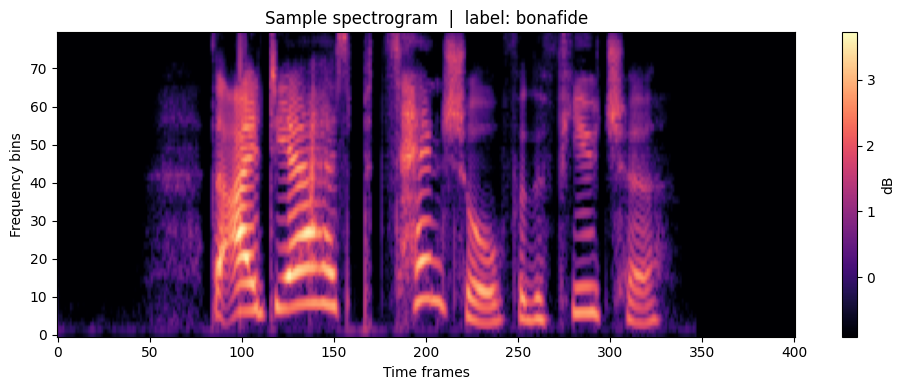

In [11]:
# -----------------------------------------------------------
# 3F. BUILD DATASETS + QUICK VISUAL CHECK
# -----------------------------------------------------------

FEATURE_TYPE = "log_mel"   # change to "lfcc" for LA experiments

print("Building datasets with feature type: " + FEATURE_TYPE)

train_ds = make_dataset(train_paths, train_labels,
                        feature_type=FEATURE_TYPE, shuffle=True)
dev_ds   = make_dataset(dev_paths,   dev_labels,
                        feature_type=FEATURE_TYPE, shuffle=False)
eval_ds  = make_dataset(eval_paths,  eval_labels,
                        feature_type=FEATURE_TYPE, shuffle=False)

print("Train batches : " + str(len(train_ds)))
print("Dev   batches : " + str(len(dev_ds)))
print("Eval  batches : " + str(len(eval_ds)))

# peek at one batch to confirm shapes are correct
for batch_features, batch_labels in train_ds.take(1):
    print("Feature batch shape : " + str(batch_features.shape))
    print("Label   batch shape : " + str(batch_labels.shape))
    print("Label values sample : " + str(batch_labels.numpy()[:8]))

# visualise one spectrogram so you can SEE what the model sees
sample_features, sample_label = next(iter(
    make_dataset(train_paths[:1], train_labels[:1],
                 feature_type=FEATURE_TYPE,
                 shuffle=False, batch_size=1)
))

plt.figure(figsize=(10, 4))
plt.imshow(
    sample_features[0, :, :, 0].numpy(),
    aspect="auto",
    origin="lower",
    cmap="magma"
)
plt.colorbar(label="dB")
plt.xlabel("Time frames")
plt.ylabel("Frequency bins")
plt.title("Sample spectrogram  |  label: " +
          ("bonafide" if sample_label[0] == 0 else "spoof"))
plt.tight_layout()
plt.show()

In [12]:
# ── STEP 4: CNN SPECTRAL BRANCH ──────────────────────────────────────


from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, BatchNormalization, MaxPooling2D,
    Dropout, Flatten, Dense, Input
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    BatchNormalization,
    MaxPooling2D,
    GlobalAveragePooling2D,
    Dropout,
    Flatten,
    Dense,
    Input,
    Concatenate
)

In [13]:
# -----------------------------------------------------------
# 4A. CNN BRANCH — FIXED to reduce overfitting
# -----------------------------------------------------------

def build_cnn_branch(input_shape):
    """
    Sequential CNN adapted for spectrogram-based spoof detection.

    FIX APPLIED: Flatten() + Dense(512) replaced with
    GlobalAveragePooling2D(). The old Flatten() turned
    (10, 50, 256) into a 128,000-length vector, which fed
    into Dense(512) — that single layer alone had about
    65 MILLION parameters. With only ~25K training files,
    the model had far more capacity than data, so it
    memorised training spectrograms instead of learning
    general spoof artefacts (train_auc -> 1.0 while
    val_loss kept climbing).

    GlobalAveragePooling2D collapses (10, 50, 256) directly
    into (256,) by averaging each channel across all
    spatial positions — zero extra parameters, and it
    forces the network to rely on CONSISTENT patterns
    across the whole spectrogram rather than memorising
    exact pixel positions.

    Layer by layer:
        Conv2D(64)  → finds basic edges and textures
                      in the spectrogram image
        MaxPool     → shrinks the image by half,
                      keeps the strongest features
        Dropout     → randomly turns off neurons
                      during training to prevent memorising

        Conv2D(128) → finds more complex patterns
                      like harmonic shapes and pitch contours

        Conv2D(256) → finds high-level fake artefacts
                      specific to TTS or replay attacks

        GlobalAvgPool → averages each of the 256 channels
                      across all time/frequency positions
                      (10, 50, 256) → (256,) — no parameters,
                      strongly regularising by design

        Dense(256)  → light refinement of the pooled features,
                      output embedding vector for fusion
    """

    n_frames = MAX_SAMPLES // HOP_LENGTH + 1   # = 401

    model = Sequential([

        # ── BLOCK 1 ─────────────────────────────────────
        # input: (batch, 80, 401, 1)
        Conv2D(
            64, (3, 3),
            activation  = "relu",
            padding     = "same",
            input_shape = input_shape    # (80, 401, 1)
        ),
        BatchNormalization(),
        # (80, 401) → (40, 200)
        MaxPooling2D(2, 2),
        # FIX: dropout raised slightly 0.25 → 0.3
        Dropout(0.3),

        # ── BLOCK 2 ─────────────────────────────────────
        # input: (batch, 40, 200, 64)
        Conv2D(128, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        # (40, 200) → (20, 100)
        MaxPooling2D(2, 2),
        Dropout(0.3),

        # ── BLOCK 3 ─────────────────────────────────────
        # input: (batch, 20, 100, 128)
        Conv2D(256, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        # (20, 100) → (10, 50)
        MaxPooling2D(2, 2),
        Dropout(0.3),

        # ── FIX: GLOBAL AVERAGE POOLING ─────────────────
        # OLD (removed): Flatten() -> Dense(512) -> Dense(256)
        #   - Flatten created a 128,000-d vector
        #   - Dense(512) on that vector = ~65M parameters
        #   - this was the main source of overfitting
        #
        # NEW: collapses (10, 50, 256) -> (256,) directly
        # zero parameters, strong built-in regularisation
        GlobalAveragePooling2D(),
        # shape: (batch, 256)

        # ── EMBEDDING OUTPUT ─────────────────────────────
        # light dense layer to refine pooled features
        # FIX: dropout raised 0.5 → 0.4 here is fine since
        # GlobalAvgPool already removed most overfitting risk
        Dense(256, activation="relu"),
        BatchNormalization(),
        Dropout(0.4),

    ], name="cnn_branch")

    return model

In [14]:
# -----------------------------------------------------------
# 4B. BUILD + INSPECT
# -----------------------------------------------------------

# input shape: (freq_bins, time_frames, channels)
n_frames     = MAX_SAMPLES // HOP_LENGTH + 1   # 401
CNN_INPUT    = (N_MELS, n_frames, 1)           # (80, 401, 1)

print("Building CNN branch...")
print("Input shape : " + str(CNN_INPUT))

cnn_branch = build_cnn_branch(CNN_INPUT)
cnn_branch.summary()

Building CNN branch...
Input shape : (80, 401, 1)


Model: "cnn_branch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 80, 401, 64)    │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 80, 401, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 40, 200, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 40, 200, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 40, 200, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 40, 200, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 20, 100, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 20, 100, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 20, 100, 256)   │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 20, 100, 256)   │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 50, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 50, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 438,272 (1.67 MB)

 Trainable params: 436,864 (1.67 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [15]:
# -----------------------------------------------------------
# 4C. FORWARD PASS TEST
# -----------------------------------------------------------

print("Running forward pass test...")

for test_features, test_labels in train_ds.take(1):
    cnn_out = cnn_branch(test_features, training=False)
    print("Input  shape : " + str(test_features.shape))
    print("Output shape : " + str(cnn_out.shape))
    # expected: (32, 256)

assert cnn_out.shape[-1] == 256, "CNN output must be 256-d for fusion"
print("CNN branch OK — output: " + str(cnn_out.shape))

Running forward pass test...


I0000 00:00:1782049823.854832      58 cuda_dnn.cc:529] Loaded cuDNN version 91002


Input  shape : (32, 80, 401, 1)
Output shape : (32, 256)
CNN branch OK — output: (32, 256)


In [16]:
# ── STEP 6 (REVISED): FUSION + FULL MODEL — SELF CONTAINED ──────────

import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Dense, BatchNormalization,
    Dropout, Concatenate
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam


# -----------------------------------------------------------
# WEIGHTED LOSS — defined HERE so no dependency on Step 7
# -----------------------------------------------------------

def make_weighted_loss(class_weights):
    w0 = tf.constant(class_weights[0], dtype=tf.float32)
    w1 = tf.constant(class_weights[1], dtype=tf.float32)

    def weighted_bce(y_true, y_pred):
        y_true  = tf.cast(y_true, tf.float32)
        bce     = tf.keras.losses.binary_crossentropy(y_true, y_pred)
        weights = y_true * w1 + (1.0 - y_true) * w0
        return tf.reduce_mean(bce * weights)

    return weighted_bce

weighted_loss = make_weighted_loss(class_weights)
print("Weighted loss created.")
print("Bonafide weight : " + str(round(class_weights[0], 3)))
print("Spoof    weight : " + str(round(class_weights[1], 3)))


# -----------------------------------------------------------
# POSITIONAL ENCODING
# -----------------------------------------------------------

def positional_encoding(max_len, d_model):
    positions = np.arange(max_len)[:, np.newaxis]
    dims      = np.arange(d_model)[np.newaxis, :]
    angles    = positions / np.power(
        10000, (2 * (dims // 2)) / np.float32(d_model)
    )
    angles[:, 0::2] = np.sin(angles[:, 0::2])
    angles[:, 1::2] = np.cos(angles[:, 1::2])
    return tf.cast(angles[np.newaxis, ...], dtype=tf.float32)


# -----------------------------------------------------------
# TRANSFORMER ENCODER BLOCK
# -----------------------------------------------------------

def transformer_encoder_block(x, d_model, num_heads, dff, dropout_rate=0.1):
    attn_input  = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
    attn_output = tf.keras.layers.MultiHeadAttention(
        num_heads = num_heads,
        key_dim   = d_model // num_heads,
        dropout   = dropout_rate
    )(attn_input, attn_input)
    attn_output = tf.keras.layers.Dropout(dropout_rate)(attn_output)
    x = tf.keras.layers.Add()([x, attn_output])

    ffn_input = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
    ffn       = tf.keras.layers.Dense(dff, activation="relu")(ffn_input)
    ffn       = tf.keras.layers.Dropout(dropout_rate)(ffn)
    ffn       = tf.keras.layers.Dense(d_model)(ffn)
    ffn       = tf.keras.layers.Dropout(dropout_rate)(ffn)
    x = tf.keras.layers.Add()([x, ffn])
    return x


# -----------------------------------------------------------
# FULL HYBRID MODEL
# -----------------------------------------------------------

def build_hybrid_model_trainable(input_shape):
    inputs = Input(shape=input_shape, name="spectrogram_input")

    # ── CNN BRANCH ───────────────────────────────────────
    c = cnn_branch(inputs)
    # shape: (batch, 256)

    # ── TRANSFORMER BRANCH ───────────────────────────────
    t = tf.keras.layers.Lambda(
        lambda x: tf.squeeze(x, axis=-1),
        name="squeeze_channel"
    )(inputs)
    t = tf.keras.layers.Permute((2, 1), name="transpose_seq")(t)

    d_model  = 128
    n_frames = input_shape[1]

    t = tf.keras.layers.Dense(d_model, name="frame_proj")(t)
    t = tf.keras.layers.Dropout(0.1, name="proj_drop")(t)

    pos_enc = positional_encoding(n_frames, d_model)
    t = tf.keras.layers.Lambda(
        lambda x: x + pos_enc,
        name="pos_enc"
    )(t)

    t = transformer_encoder_block(t, d_model=128, num_heads=4, dff=256)
    t = transformer_encoder_block(t, d_model=128, num_heads=4, dff=256)

    t = tf.keras.layers.GlobalAveragePooling1D(name="temporal_pool")(t)

    t = tf.keras.layers.Dense(256, use_bias=False, name="transformer_proj")(t)
    t = tf.keras.layers.LayerNormalization(name="transformer_ln")(t)
    t = tf.keras.layers.ReLU(name="transformer_relu")(t)
    # shape: (batch, 256)

    # ── FUSION ───────────────────────────────────────────
    fused = Concatenate(name="fusion_concat")([c, t])
    # shape: (batch, 512)

    # ── CLASSIFIER HEAD ──────────────────────────────────
    x = Dense(256, activation="relu", name="fusion_dense1")(fused)
    x = BatchNormalization(name="fusion_bn1")(x)
    x = Dropout(0.5, name="fusion_drop1")(x)

    x = Dense(128, activation="relu", name="fusion_dense2")(x)
    x = BatchNormalization(name="fusion_bn2")(x)
    x = Dropout(0.3, name="fusion_drop2")(x)

    output = Dense(1, activation="sigmoid", name="output")(x)

    model = Model(
        inputs  = inputs,
        outputs = output,
        name    = "hybrid_asvspoof_model"
    )
    return model


# -----------------------------------------------------------
# BUILD + COMPILE
# -----------------------------------------------------------

print("Building full hybrid model...")
model = build_hybrid_model_trainable(CNN_INPUT)

model.compile(
    optimizer = Adam(learning_rate=0.001),
    loss      = weighted_loss,
    metrics   = [
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

model.summary()


# -----------------------------------------------------------
# QUICK END-TO-END CHECK
# -----------------------------------------------------------

print("Running end-to-end forward pass test...")

for test_features, test_labels in train_ds.take(1):
    preds = model(test_features, training=False)
    print("Input  shape : " + str(test_features.shape))
    print("Output shape : " + str(preds.shape))
    print("Sample scores: " + str(preds.numpy()[:5].flatten().round(3)))
    print("Sample labels: " + str(test_labels.numpy()[:5]))

print("Model ready for training!")

Weighted loss created.
Bonafide weight : 4.919
Spoof    weight : 0.557
Building full hybrid model...


Model: "hybrid_asvspoof_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ spectrogram_input   │ (None, 80, 401,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ squeeze_channel     │ (None, 80, 401)   │          0 │ spectrogram_inpu… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transpose_seq       │ (None, 401, 80)   │          0 │ squeeze_channel[… │
│ (Permute)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ frame_proj (Dense)  │ (None, 401, 128)  │     10,368 │ transpose_seq[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ proj_drop (Dropout) │ (None, 401, 128)  │          0 │ frame_proj[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pos_enc (Lambda)    │ (None, 401, 128)  │          0 │ proj_drop[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 401, 128)  │        256 │ pos_enc[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 401, 128)  │     66,048 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 401, 128)  │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 401, 128)  │          0 │ pos_enc[0][0],    │
│                     │                   │            │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 401, 128)  │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 401, 256)  │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 401, 256)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 401, 128)  │     32,896 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 401, 128)  │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 401, 128)  │          0 │ add[0][0],        │
│                     │                   │            │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 401, 128)  │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 401, 128)  │     66,048 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 401, 128)  │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 401, 128)  │          0 │ add_1[0][0],    

 Total params: 912,769 (3.48 MB)

 Trainable params: 910,593 (3.47 MB)

 Non-trainable params: 2,176 (8.50 KB)

Running end-to-end forward pass test...
Input  shape : (32, 80, 401, 1)
Output shape : (32, 1)
Sample scores: [0.452 0.465 0.511 0.455 0.435]
Sample labels: [1 1 1 1 1]
Model ready for training!


In [17]:
# ── STEP 7: TRAINING LOOP ────────────────────────────────────────────

In [18]:
# ── STEP 7 (FIXED): TRAINING LOOP ───────────────────────────────────

import os
import tensorflow as tf
from tensorflow.keras.optimizers import Adam


# -----------------------------------------------------------
# 7A. WEIGHTED LOSS — unchanged
# -----------------------------------------------------------

def make_weighted_loss(class_weights):
    w0 = tf.constant(class_weights[0], dtype=tf.float32)
    w1 = tf.constant(class_weights[1], dtype=tf.float32)

    def weighted_bce(y_true, y_pred):
        y_true  = tf.cast(y_true, tf.float32)
        bce     = tf.keras.losses.binary_crossentropy(y_true, y_pred)
        weights = y_true * w1 + (1.0 - y_true) * w0
        return tf.reduce_mean(bce * weights)

    return weighted_bce

weighted_loss = make_weighted_loss(class_weights)
print("Weighted loss created.")


# -----------------------------------------------------------
# 7B. RECOMPILE with weighted loss
# -----------------------------------------------------------

model.compile(
    optimizer = Adam(learning_rate=0.0003, clipnorm=1.0),   # ← clipnorm added
    loss      = weighted_loss,
    metrics   = [
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc")
    ]
)
print("Model compiled.")


# -----------------------------------------------------------
# 7C. CALLBACKS — fixed for Keras 3.x
# -----------------------------------------------------------

CHECKPOINT_DIR  = "/kaggle/working/checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
BEST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, "best_model.keras")


# CALLBACK 1: save best model
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath          = BEST_MODEL_PATH,
    monitor           = "val_auc",
    mode              = "max",
    save_best_only    = True,
    save_weights_only = False,
    verbose           = 1
)


# CALLBACK 2: reduce LR on plateau
# FIXED: use factor and patience, no backend.set_value needed
# Keras 3.x ReduceLROnPlateau handles LR internally correctly
reduce_lr_cb = tf.keras.callbacks.ReduceLROnPlateau(
    monitor  = "val_auc",
    mode     = "max",
    factor   = 0.5,
    patience = 2,        # was 3 — reacts one epoch sooner
    min_lr   = 1e-7,
    verbose  = 1
)


# CALLBACK 3: early stopping
early_stop_cb = tf.keras.callbacks.EarlyStopping(
    monitor              = "val_auc",
    mode                 = "max",
    patience             = 7,
    restore_best_weights = True,
    verbose              = 1
)


# CALLBACK 4: CSV logger
csv_logger_cb = tf.keras.callbacks.CSVLogger(
    "/kaggle/working/training_log.csv",
    append = False
)


# CALLBACK 5: LR logger — FIXED for Keras 3.x
# old approach used tf.keras.backend.set_value() which broke
# new approach reads the LR directly from optimizer config
class LRLogger(tf.keras.callbacks.Callback):
    def on_epoch_begin(self, epoch, logs=None):
        # FIXED: use float() on the optimizer's learning_rate
        # works in both Keras 2.x and 3.x
        try:
            lr = float(
                tf.keras.backend.get_value(
                    self.model.optimizer.learning_rate
                )
            )
        except Exception:
            # fallback for Keras 3.x where get_value may fail
            lr = float(self.model.optimizer.learning_rate)
        print("  Epoch " + str(epoch + 1) +
              " | learning rate: " + "{:.8f}".format(lr))

lr_logger_cb = LRLogger()


# CALLBACK 6: Warmup scheduler — FIXED for Keras 3.x
# root cause of the crash was here:
#     tf.keras.backend.set_value(model.optimizer.learning_rate, new_lr)
# in Keras 3.x optimizer.learning_rate is a float, not a Variable
# fix: use optimizer.learning_rate.assign() OR reassign directly

class WarmupScheduler(tf.keras.callbacks.Callback):
    """
    Linearly increases LR from start_lr to target_lr
    over the first warmup_epochs epochs.

    FIXED: uses self.model.optimizer.learning_rate = new_lr
    instead of tf.keras.backend.set_value() which broke in Keras 3.x
    """
    def __init__(self, warmup_epochs=3, target_lr=0.001):
        super().__init__()
        self.warmup_epochs = warmup_epochs
        self.target_lr     = target_lr
        self.start_lr      = target_lr / 10.0   # start at 10% of target

    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            # linear interpolation from start_lr to target_lr
            progress = (epoch + 1) / self.warmup_epochs
            new_lr   = self.start_lr + progress * (
                self.target_lr - self.start_lr
            )

            # FIXED: directly assign the new float value
            # this works in both Keras 2.x and 3.x
            self.model.optimizer.learning_rate = float(new_lr)

            print("  Warmup epoch " + str(epoch + 1) +
                  " | lr → " + "{:.8f}".format(new_lr))

warmup_cb = WarmupScheduler(warmup_epochs=3, target_lr=0.0003)

print("All callbacks created.")




import time

# CALLBACK 7: Epoch Time Logger
class EpochTimeLogger(tf.keras.callbacks.Callback):
    def on_epoch_begin(self, epoch, logs=None):
        # Record the start time of the epoch
        self.epoch_start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        # Calculate how long the epoch took
        epoch_duration = time.time() - self.epoch_start_time
        
        # Print it directly to the console
        print(f"  --> Epoch {epoch + 1} time: {epoch_duration:.2f} seconds")
        
        # Add it to the logs so your CSVLogger records it automatically
        logs["time_seconds"] = epoch_duration

epoch_time_cb = EpochTimeLogger()

Weighted loss created.
Model compiled.
All callbacks created.


In [19]:
# -----------------------------------------------------------
# 7D. RUN TRAINING
# -----------------------------------------------------------

EPOCHS = 5

print("Starting training...")
print("Train batches per epoch : " + str(len(train_ds)))
print("Dev   batches per epoch : " + str(len(dev_ds)))
print("")

history = model.fit(
    train_ds,
    validation_data = dev_ds,
    epochs          = EPOCHS,
    callbacks       = [
        warmup_cb,
        checkpoint_cb,
        reduce_lr_cb,
        early_stop_cb,
        csv_logger_cb,
        lr_logger_cb,
        epoch_time_cb
    ],
    verbose = 1
)

print("")
print("Training complete!")
print("Best model saved at: " + BEST_MODEL_PATH)



Starting training...
Train batches per epoch : 793
Dev   batches per epoch : 776

  Warmup epoch 1 | lr → 0.00012000
  Epoch 1 | learning rate: 0.00012000
Epoch 1/5


I0000 00:00:1782049836.784499     105 service.cc:152] XLA service 0x7f6fa400ce60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782049836.784550     105 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0


  2/793 ━━━━━━━━━━━━━━━━━━━━ 54s 69ms/step - accuracy: 0.5156 - auc: 0.4378 - loss: 1.0334   

I0000 00:00:1782049857.383498     105 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


793/793 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 0.6152 - auc: 0.6446 - loss: 0.7417
Epoch 1: val_auc improved from None to 0.77012, saving model to /kaggle/working/checkpoints/best_model.keras

Epoch 1: finished saving model to /kaggle/working/checkpoints/best_model.keras
  --> Epoch 1 time: 495.43 seconds
793/793 ━━━━━━━━━━━━━━━━━━━━ 495s 587ms/step - accuracy: 0.7129 - auc: 0.7514 - loss: 0.5876 - val_accuracy: 0.7126 - val_auc: 0.7701 - val_loss: 0.8115 - learning_rate: 1.2000e-04 - time_seconds: 495.4258
  Warmup epoch 2 | lr → 0.00021000
  Epoch 2 | learning rate: 0.00021000
Epoch 2/5
793/793 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - accuracy: 0.9110 - auc: 0.8933 - loss: 0.2865
Epoch 2: val_auc improved from 0.77012 to 0.80746, saving model to /kaggle/working/checkpoints/best_model.keras

Epoch 2: finished saving model to /kaggle/working/checkpoints/best_model.keras
  --> Epoch 2 time: 458.18 seconds
793/793 ━━━━━━━━━━━━━━━━━━━━ 458s 578ms/step - accuracy: 0.9330 - auc: 0.9122 

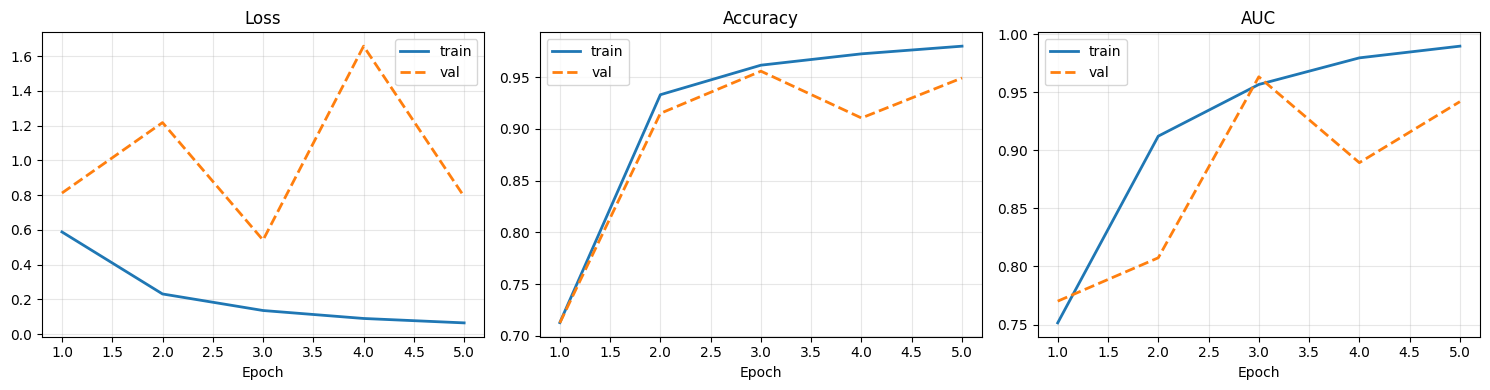

Training curves saved.


In [20]:

# -----------------------------------------------------------
# 7E. PLOT TRAINING CURVES
# -----------------------------------------------------------

import matplotlib.pyplot as plt

def plot_training_history(history):
    epochs_ran = len(history.history["loss"])
    epoch_axis = range(1, epochs_ran + 1)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(epoch_axis, history.history["loss"],
                 label="train", linewidth=2)
    axes[0].plot(epoch_axis, history.history["val_loss"],
                 label="val", linewidth=2, linestyle="--")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epoch_axis, history.history["accuracy"],
                 label="train", linewidth=2)
    axes[1].plot(epoch_axis, history.history["val_accuracy"],
                 label="val", linewidth=2, linestyle="--")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(epoch_axis, history.history["auc"],
                 label="train", linewidth=2)
    axes[2].plot(epoch_axis, history.history["val_auc"],
                 label="val", linewidth=2, linestyle="--")
    axes[2].set_title("AUC")
    axes[2].set_xlabel("Epoch")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("/kaggle/working/training_curves.png", dpi=150)
    plt.show()
    print("Training curves saved.")

plot_training_history(history)

In [23]:
# ── STEP 8: FULL EVALUATION ──────────────────────────────────────────

from sklearn.metrics import (
    roc_curve, auc, confusion_matrix,
    ConfusionMatrixDisplay, classification_report
)
from scipy.optimize import brentq
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

Plotting score distribution...


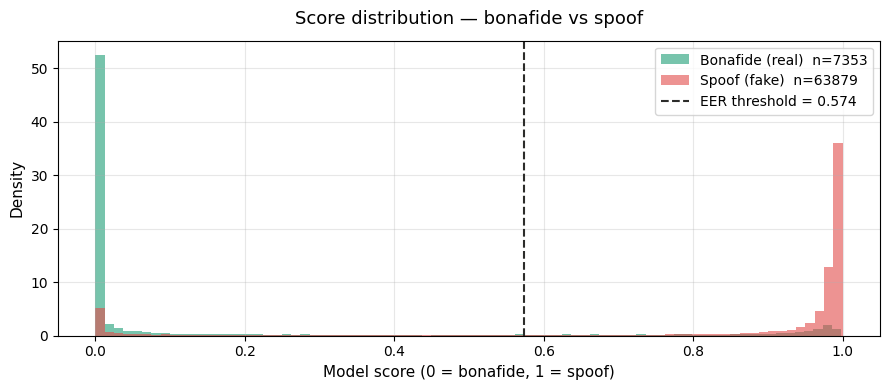

Score distribution saved.


In [47]:
# -----------------------------------------------------------
# 8F. SCORE DISTRIBUTION PLOT
# Shows how well the model separates bonafide from spoof
# -----------------------------------------------------------

def plot_score_distribution(labels, scores, threshold):
    """
    Plots the histogram of model scores for bonafide vs spoof.

    A well-trained model produces:
        bonafide scores → cluster near 0.0
        spoof    scores → cluster near 1.0
    With a clear gap between them.

    A poorly trained model:
        both distributions heavily overlap in the middle

    The EER threshold (vertical line) is where
    the two distributions cross — the optimal decision boundary.
    """
    bonafide_scores = scores[labels == 0]
    spoof_scores    = scores[labels == 1]

    fig, ax = plt.subplots(figsize=(9, 4))

    ax.hist(
        bonafide_scores,
        bins      = 80,
        alpha     = 0.6,
        color     = "#1D9E75",
        label     = "Bonafide (real)  n=" + str(len(bonafide_scores)),
        density   = True
    )
    ax.hist(
        spoof_scores,
        bins      = 80,
        alpha     = 0.6,
        color     = "#E24B4A",
        label     = "Spoof (fake)  n=" + str(len(spoof_scores)),
        density   = True
    )

    # draw EER threshold line
    ax.axvline(
        x         = threshold,
        color     = "#2C2C2A",
        linewidth = 1.5,
        linestyle = "--",
        label     = "EER threshold = " + str(round(threshold, 3))
    )

    ax.set_xlabel("Model score (0 = bonafide, 1 = spoof)", fontsize=11)
    ax.set_ylabel("Density", fontsize=11)
    ax.set_title(
        "Score distribution — bonafide vs spoof",
        fontsize=13, pad=12
    )
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("/kaggle/working/score_distribution.png", dpi=150)
    plt.show()
    print("Score distribution saved.")


print("Plotting score distribution...")
plot_score_distribution(eval_labels, eval_scores, eer_threshold)

In [51]:
# -----------------------------------------------------------
# 8H. FINAL SUMMARY TABLE
# All metrics in one place
# -----------------------------------------------------------

tn, fp, fn, tp = confusion_matrix(eval_labels, eval_predictions).ravel()

precision_spoof   = tp / (tp + fp + 1e-9)
recall_spoof      = tp / (tp + fn + 1e-9)
f1_spoof          = 2 * precision_spoof * recall_spoof / (
                    precision_spoof + recall_spoof + 1e-9)

precision_bonafide = tn / (tn + fn + 1e-9)
recall_bonafide    = tn / (tn + fp + 1e-9)

print("")
print("=" * 45)
print("   FINAL EVALUATION RESULTS")
print("=" * 45)
print("  EER                  : " + str(round(eer, 4)))
print("  AUC                  : " + str(round(roc_auc, 4)))
print("  EER threshold        : " + str(round(eer_threshold, 4)))
print("")
print("  Spoof detection")
print("    Precision        : " + str(round(precision_spoof, 4)))
print("    Recall           : " + str(round(recall_spoof, 4)))
print("    F1 score         : " + str(round(f1_spoof, 4)))
print("")
print("  Bonafide detection")
print("    Precision        : " + str(round(precision_bonafide, 4)))
print("    Recall           : " + str(round(recall_bonafide, 4)))
print("")
print("  Confusion matrix")
print("    TN (real → real) : " + str(tn))
print("    FP (real → fake) : " + str(fp))
print("    FN (fake → real) : " + str(fn))
print("    TP (fake → fake) : " + str(tp))
print("=" * 45)

# save summary to text file
with open("/kaggle/working/evaluation_summary.txt", "w") as f:
    f.write("EER       : " + str(round(eer, 4)) + "\n")
    f.write("AUC       : " + str(round(roc_auc, 4)) + "\n")
    f.write("Threshold : " + str(round(eer_threshold, 4)) + "\n")
    f.write("TP        : " + str(tp) + "\n")
    f.write("TN        : " + str(tn) + "\n")
    f.write("FP        : " + str(fp) + "\n")
    f.write("FN        : " + str(fn) + "\n")

print("Summary saved to evaluation_summary.txt")


   FINAL EVALUATION RESULTS
  EER                  : 0.1601
  AUC                  : 0.9173
  EER threshold        : 0.5737

  Spoof detection
    Precision        : 0.9785
    Recall           : 0.84
    F1 score         : 0.904

  Bonafide detection
    Precision        : 0.3767
    Recall           : 0.8399

  Confusion matrix
    TN (real → real) : 6176
    FP (real → fake) : 1177
    FN (fake → real) : 10221
    TP (fake → fake) : 53658
Summary saved to evaluation_summary.txt


Loading best weights into existing model...
Best weights loaded successfully!

Starting final evaluation on the eval_ds...
2226/2226 ━━━━━━━━━━━━━━━━━━━━ 547s 244ms/step - accuracy: 0.8475 - auc: 0.9101 - loss: 0.7932
Generating predictions...
2226/2226 ━━━━━━━━━━━━━━━━━━━━ 562s 251ms/step


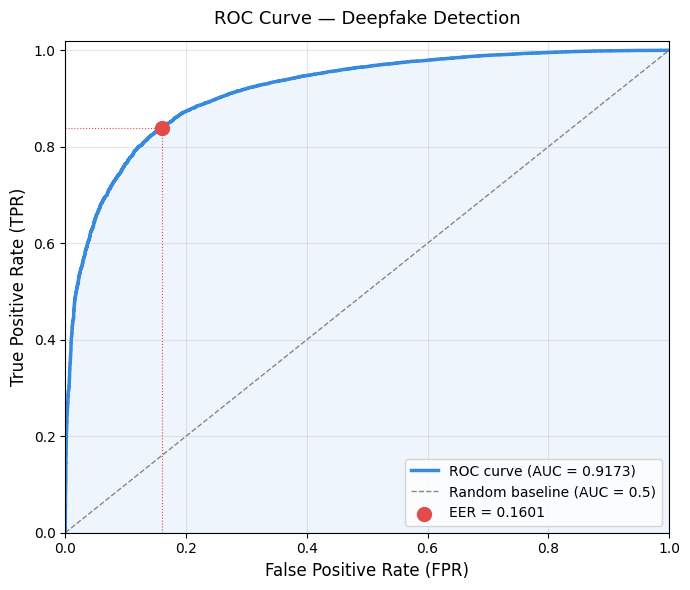

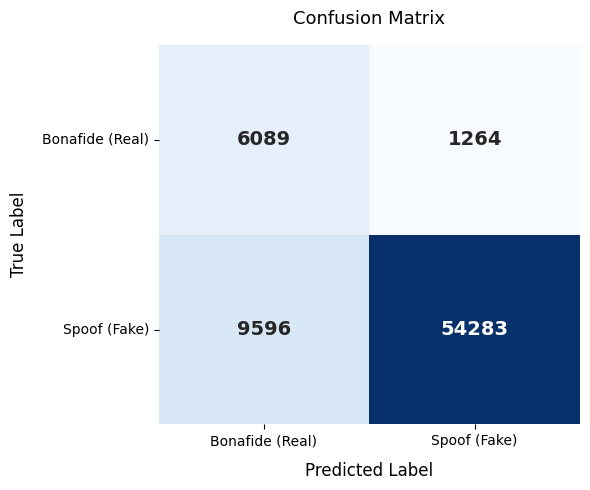


   FINAL MODEL EVALUATION (SPOOF DETECTION)
  Accuracy             : 0.8475
  EER                  : 0.1601
  AUC                  : 0.9173
  EER Threshold        : 0.5737
---------------------------------------------
  Precision (Spoof)    : 0.9772
  Recall (Spoof)       : 0.8498
  F1 Score             : 0.9091
---------------------------------------------
  Confusion Matrix:
    TP (Correctly Blocked Fake) : 54283
    TN (Correctly Passed Real)  : 6089
    FP (Wrongly Blocked Real)   : 1264
    FN (Wrongly Passed Fake)    : 9596
All charts and summaries saved to /kaggle/working/


In [54]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix
from scipy.optimize import brentq
from scipy.interpolate import interp1d

# ===========================================================
# 8A. LOAD BEST MODEL WEIGHTS (Bypass Keras 3 Bug)
# ===========================================================
print("Loading best weights into existing model...")
BEST_MODEL_PATH = "/kaggle/working/checkpoints/best_model.keras"
model.load_weights(BEST_MODEL_PATH)
best_model = model 
print("Best weights loaded successfully!")

# ===========================================================
# 8B. COMPILE & EVALUATE ON UNSEEN DATA
# ===========================================================
print("\nStarting final evaluation on the eval_ds...")
best_model.compile(
    loss=weighted_loss,
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc")
    ]
)
results = best_model.evaluate(eval_ds, verbose=1)

# Generate raw prediction scores (probabilities) and binary classes
print("Generating predictions...")
eval_scores = best_model.predict(eval_ds, verbose=1)
eval_predictions = (eval_scores > 0.5).astype(int)

# ===========================================================
# 8C. COMPUTE EQUAL ERROR RATE (EER)
# ===========================================================
def compute_eer(labels, scores):
    fpr, tpr, thresholds = roc_curve(labels, scores, pos_label=1)
    fnr = 1.0 - tpr
    eer = brentq(lambda x: x - interp1d(fpr, fnr)(x), 0.0, 1.0)
    eer_threshold = interp1d(fpr, thresholds)(eer)
    return float(eer), float(eer_threshold), fpr, tpr, thresholds

eer, eer_threshold, fpr, tpr, thresholds = compute_eer(eval_labels, eval_scores)
roc_auc = auc(fpr, tpr)

# ===========================================================
# 8D. PLOT ROC CURVE
# ===========================================================
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color="#378ADD", linewidth=2.5, label=f"ROC curve (AUC = {roc_auc:.4f})")
ax.plot([0, 1], [0, 1], color="#888780", linewidth=1, linestyle="--", label="Random baseline (AUC = 0.5)")

eer_fpr, eer_tpr = eer, 1.0 - eer
ax.scatter([eer_fpr], [eer_tpr], color="#E24B4A", s=100, zorder=5, label=f"EER = {eer:.4f}")
ax.plot([eer_fpr, eer_fpr], [0, eer_tpr], color="#E24B4A", linewidth=0.8, linestyle=":")
ax.plot([0, eer_fpr], [eer_tpr, eer_tpr], color="#E24B4A", linewidth=0.8, linestyle=":")
ax.fill_between(fpr, tpr, alpha=0.08, color="#378ADD")

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])
ax.set_xlabel("False Positive Rate (FPR)", fontsize=12)
ax.set_ylabel("True Positive Rate (TPR)", fontsize=12)
ax.set_title("ROC Curve — Deepfake Detection", fontsize=13, pad=12)
ax.legend(loc="lower right", fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/kaggle/working/roc_curve.png", dpi=150)
plt.show()

# ===========================================================
# 8E. PLOT CONFUSION MATRIX
# ===========================================================
cm = confusion_matrix(eval_labels, eval_predictions)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, annot_kws={"size": 14, "weight": "bold"}, ax=ax)
ax.set_title("Confusion Matrix", fontsize=13, pad=15)
ax.set_xlabel("Predicted Label", fontsize=12, labelpad=10)
ax.set_ylabel("True Label", fontsize=12, labelpad=10)
ax.set_xticklabels(["Bonafide (Real)", "Spoof (Fake)"])
ax.set_yticklabels(["Bonafide (Real)", "Spoof (Fake)"], rotation=0)
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix.png", dpi=150)
plt.show()

# ===========================================================
# 8F. FINAL SUMMARY & METRICS
# ===========================================================
tn, fp, fn, tp = cm.ravel()

accuracy  = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp + 1e-9)
recall    = tp / (tp + fn + 1e-9)
f1_score  = 2 * (precision * recall) / (precision + recall + 1e-9)

print("\n" + "=" * 45)
print("   FINAL MODEL EVALUATION (SPOOF DETECTION)")
print("=" * 45)
print(f"  Accuracy             : {accuracy:.4f}")
print(f"  EER                  : {eer:.4f}")
print(f"  AUC                  : {roc_auc:.4f}")
print(f"  EER Threshold        : {eer_threshold:.4f}")
print("-" * 45)
print(f"  Precision (Spoof)    : {precision:.4f}")
print(f"  Recall (Spoof)       : {recall:.4f}")
print(f"  F1 Score             : {f1_score:.4f}")
print("-" * 45)
print("  Confusion Matrix:")
print(f"    TP (Correctly Blocked Fake) : {tp}")
print(f"    TN (Correctly Passed Real)  : {tn}")
print(f"    FP (Wrongly Blocked Real)   : {fp}")
print(f"    FN (Wrongly Passed Fake)    : {fn}")
print("=" * 45)

# Save to text file
with open("/kaggle/working/evaluation_summary.txt", "w") as f:
    f.write(f"Accuracy  : {accuracy:.4f}\n")
    f.write(f"EER       : {eer:.4f}\n")
    f.write(f"AUC       : {roc_auc:.4f}\n")
    f.write(f"Precision : {precision:.4f}\n")
    f.write(f"Recall    : {recall:.4f}\n")
    f.write(f"F1 Score  : {f1_score:.4f}\n")
    f.write(f"TP: {tp} | TN: {tn} | FP: {fp} | FN: {fn}\n")

print("All charts and summaries saved to /kaggle/working/")

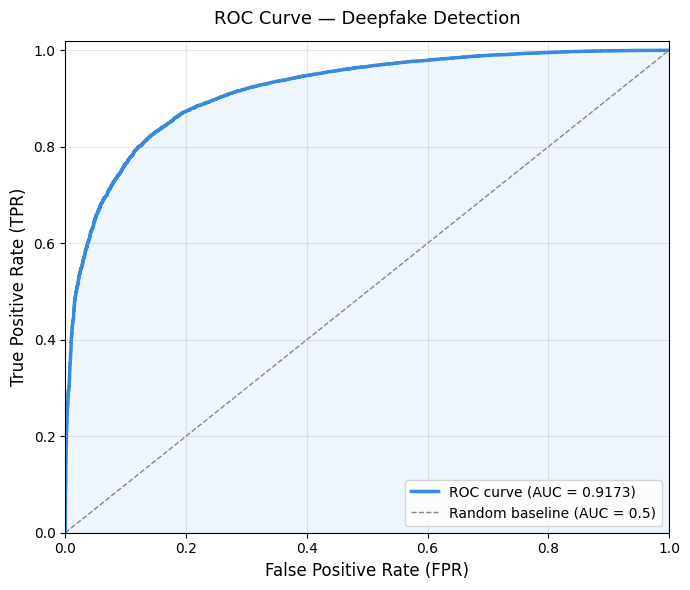

In [56]:
# ===========================================================
# 8D. PLOT ROC CURVE
# ===========================================================
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color="#378ADD", linewidth=2.5, label=f"ROC curve (AUC = {roc_auc:.4f})")
ax.plot([0, 1], [0, 1], color="#888780", linewidth=1, linestyle="--", label="Random baseline (AUC = 0.5)")

#eer_fpr, eer_tpr = eer, 1.0 - eer
#ax.scatter([eer_fpr], [eer_tpr], color="#E24B4A", s=100, zorder=5, label=f"EER = {eer:.4f}")
#ax.plot([eer_fpr, eer_fpr], [0, eer_tpr], color="#E24B4A", linewidth=0.8, linestyle=":")
#ax.plot([0, eer_fpr], [eer_tpr, eer_tpr], color="#E24B4A", linewidth=0.8, linestyle=":")
ax.fill_between(fpr, tpr, alpha=0.08, color="#378ADD")

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])
ax.set_xlabel("False Positive Rate (FPR)", fontsize=12)
ax.set_ylabel("True Positive Rate (TPR)", fontsize=12)
ax.set_title("ROC Curve — Deepfake Detection", fontsize=13, pad=12)
ax.legend(loc="lower right", fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/kaggle/working/roc_curve.png", dpi=150)
plt.show()